In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd
import os

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, \
    OrdinalEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


: 

In [ ]:
FOLDS = 10 

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE.upper()}")

Using device: CPU


In [ ]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df_original = pd.read_csv('data/Exam_Score_Prediction.csv')

# EDA

In [5]:
overview = pd.DataFrame({
    "dtype": df_train.dtypes.astype(str),
    "missing": df_train.isna().sum(),
    "missing_%": (df_train.isna().mean() * 100).round(2),
    "nunique": df_train.nunique(dropna=False),
}).sort_values(["missing", "nunique"], ascending=False)

display(overview)
display(df_train.head(3))
print("Shape:", df_train.shape)
print("Duplicate rows:", df_train.duplicated().sum())

,dtype,missing,missing_%,nunique
id,int64,0,0.0,630000
exam_score,float64,0,0.0,805
study_hours,float64,0,0.0,792
class_attendance,float64,0,0.0,617
sleep_hours,float64,0,0.0,66
age,int64,0,0.0,8
course,str,0,0.0,7
study_method,str,0,0.0,5
gender,str,0,0.0,3
sleep_quality,str,0,0.0,3


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0


Shape: (630000, 13)
Duplicate rows: 0


## Data Sanity Checks

**Quick checks**
- Missingness: the overview table above shows no missing values across columns
- Duplicates: the printed count confirms that there are no duplicate rows in this dataset
- Types: dtypes look consistent with expectations (categorical, numeric, target)

**Notes**
- Since this dataset is clean, we can direct our attention for the rest of the EDA on distributions, imbalances, and feature-target relationships.

In [6]:
cat_var = ['gender', 'course', 'sleep_quality', 'study_method', 
           'facility_rating', 'exam_difficulty', 'internet_access']
num_var = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
target = 'exam_score'

In [7]:
for c in cat_var:
    vc = df_train[c].value_counts(dropna=False).head(8)
    display(vc.to_frame("count").rename_axis(c))

,count
gender,
other,211097
male,210593
female,208310


,count
course,
b.tech,131236
b.sc,111554
b.com,110932
bca,88721
bba,75644
ba,61989
diploma,49924


,count
sleep_quality,
poor,213675
good,213089
average,203236


,count
study_method,
coaching,131697
self-study,131131
mixed,123086
group study,123009
online videos,121077


,count
facility_rating,
medium,214082
low,212378
high,203540


,count
exam_difficulty,
moderate,353982
easy,176540
hard,99478


,count
internet_access,
yes,579423
no,50577


In [8]:
course_notes = {
    "b.tech": "Bachelor of Technology",
    "b.sc": "Bachelor of Science",
    "bca": "Bachelor of Computer Applications",
    "diploma": "Diploma",
    "bba": "Bachelor of Business Administration",
    "b.com": "Bachelor of Commerce",
    "ba": "Bachelor of Arts"
}
display(pd.Series(course_notes, name="Meaning").rename_axis("course"))

course
b.tech                  Bachelor of Technology
b.sc                       Bachelor of Science
bca          Bachelor of Computer Applications
diploma                                Diploma
bba        Bachelor of Business Administration
b.com                     Bachelor of Commerce
ba                            Bachelor of Arts
Name: Meaning, dtype: str

## Categorical feature overview

**Observations**
- Mostly balanced across categories and within imbalances are never rare categories (likely won't affect model stability and evaluation too much)
- Some features may be **ordinal** (sleep_quality, facility_rating, exam_difficulty), while others are **nominal** (gender, course, study_method, internet_access)
- Course mapping above is included to make category values more readable

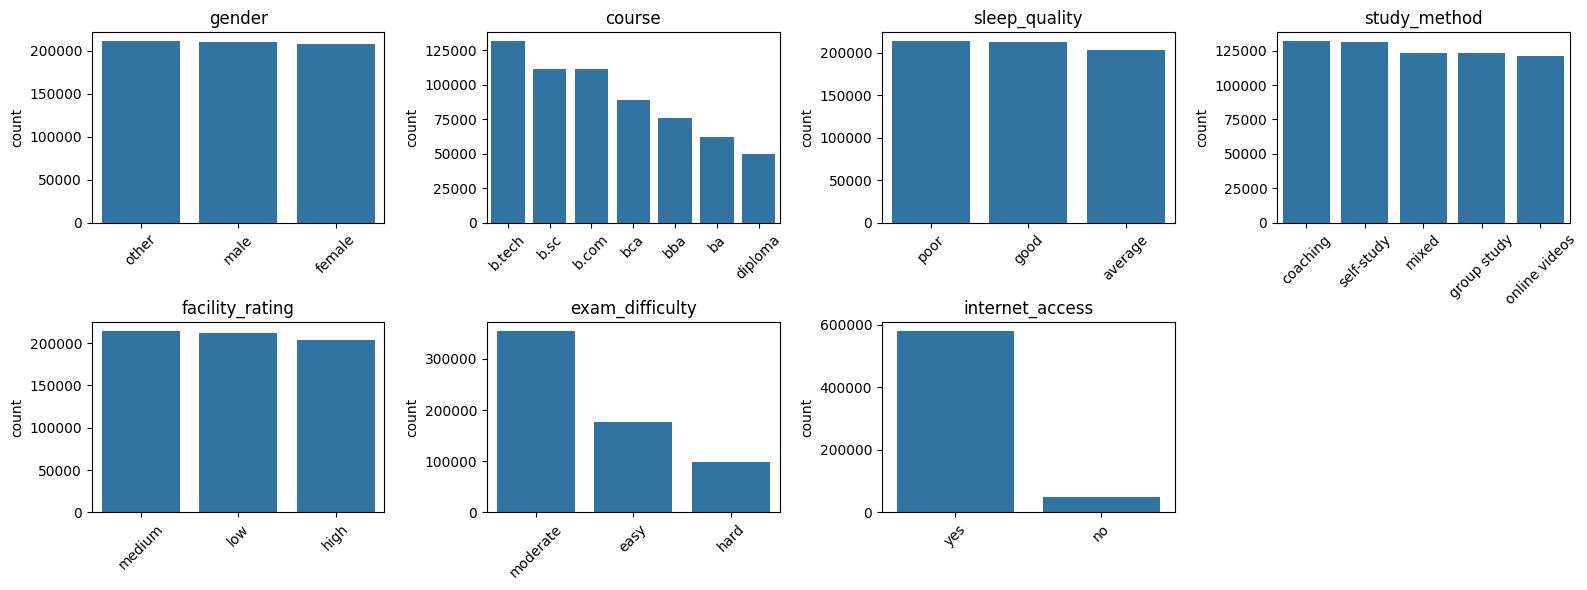

In [9]:
import math

n = len(cat_var)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = np.array(axes).ravel()

for ax, c in zip(axes, cat_var):
    order = df_train[c].value_counts().index
    sns.countplot(data=df_train, x=c, order=order, ax=ax)
    ax.set_title(c)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(cat_var):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


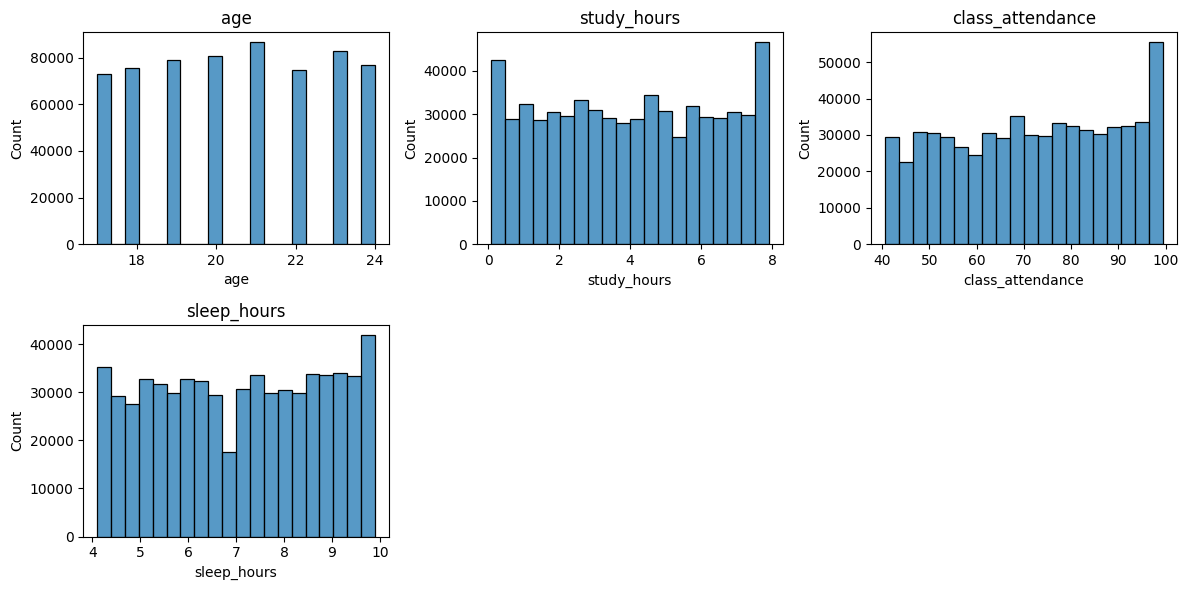

In [10]:
import math

n = len(num_var)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = np.array(axes).ravel()

for ax, c in zip(axes, num_var):
    sns.histplot(df_train[c], bins=20, ax=ax)
    ax.set_title(c)
    ax.set_xlabel(c)

for ax in axes[len(num_var):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

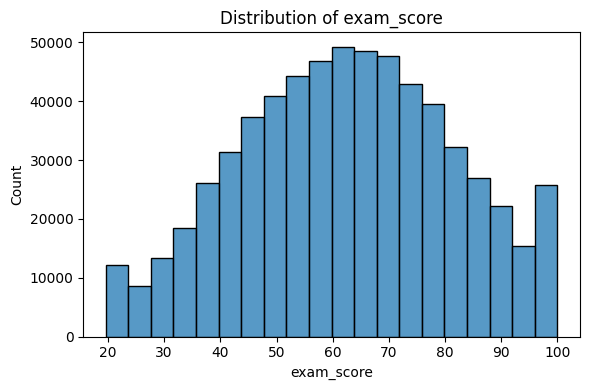

In [11]:
plt.figure(figsize=(6, 4))
sns.histplot(df_train[target], bins=20)
plt.title(f"Distribution of {target}")
plt.xlabel(target)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [12]:
display(df_train[num_var + [target]].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


## Feature-target relationships

To keep the notebook compact, I use summary plots to show:
- **Counts** (how common each value/range is), and
- **Target trend** (median exam_score) across categories or bins 

In [ ]:
# plotting function

# note created with the help of chatgpt 4o
def plot_count_and_median(df, cols, target, bins=10, ncols=3, figsize=(5, 4),
                          int_as_cat_unique_max=20, cat_order=None):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0]*ncols, figsize[1]*nrows))
    axes = np.array(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        tmp = df[[col, target]].dropna()
        if tmp.empty:
            ax.set_title(col)
            ax.axis("off")
            continue

        x = tmp[col]
        y = tmp[target]

        is_cat = (x.dtype == "object") or pd.api.types.is_string_dtype(x)

        # ---------- CATEGORICAL ----------
        if is_cat:
            counts = x.value_counts()
            med = tmp.groupby(col)[target].median()

            if cat_order is not None and col in cat_order:
                order = [v for v in cat_order[col] if v in counts.index]
                order += [v for v in sorted(counts.index) if v not in order]
            else:
                order = sorted(counts.index)

            counts = counts.loc[order]
            med = med.loc[order]

            xpos = np.arange(len(order))
            ax.bar(xpos, counts.values, zorder=1)
            ax.set_xticks(xpos)
            ax.set_xticklabels(order, rotation=45, ha="right")
            ax.set_title(col)
            ax.set_ylabel("Count")

            ax2 = ax.twinx()
            ax2.patch.set_visible(False)
            ax2.set_zorder(ax.get_zorder() + 1)
            ax2.plot(xpos, med.values, color="lightcoral", marker="o", linewidth=2, zorder=10)
            ax2.set_ylabel(f"Median {target}")

        # ---------- NUMERIC ----------
        else:
            xvals = x.to_numpy()
            yvals = y.to_numpy()

            # If numeric has low unique values (like age), treat as per-value bars
            uniq = np.sort(np.unique(xvals))
            if len(uniq) <= int_as_cat_unique_max:
                counts = np.array([(xvals == v).sum() for v in uniq])
                med = np.array([np.median(yvals[xvals == v]) for v in uniq])

                ax.bar(uniq, counts, zorder=1)
                ax.set_title(col)
                ax.set_xlabel(col)
                ax.set_ylabel("Count")

                ax2 = ax.twinx()
                ax2.patch.set_visible(False)
                ax2.set_zorder(ax.get_zorder() + 1)
                ax2.plot(uniq, med, color="lightcoral", marker="o", linewidth=2, zorder=10)
                ax2.set_ylabel(f"Median {target}")

            # Otherwise, regular histogram bins
            else:
                counts, edges = np.histogram(xvals, bins=bins)
                centers = (edges[:-1] + edges[1:]) / 2
                idx = np.digitize(xvals, edges) - 1

                med = np.array([
                    np.median(yvals[idx == j]) if np.any(idx == j) else np.nan
                    for j in range(len(centers))
                ])

                ax.bar(centers, counts, width=(edges[1] - edges[0]), zorder=1)
                ax.set_title(col)
                ax.set_xlabel(col)
                ax.set_ylabel("Count")

                ax2 = ax.twinx()
                ax2.patch.set_visible(False)
                ax2.set_zorder(ax.get_zorder() + 1)
                ax2.plot(centers, med, color="lightcoral", marker="o", linewidth=2, zorder=10)
                ax2.set_ylabel(f"Median {target}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


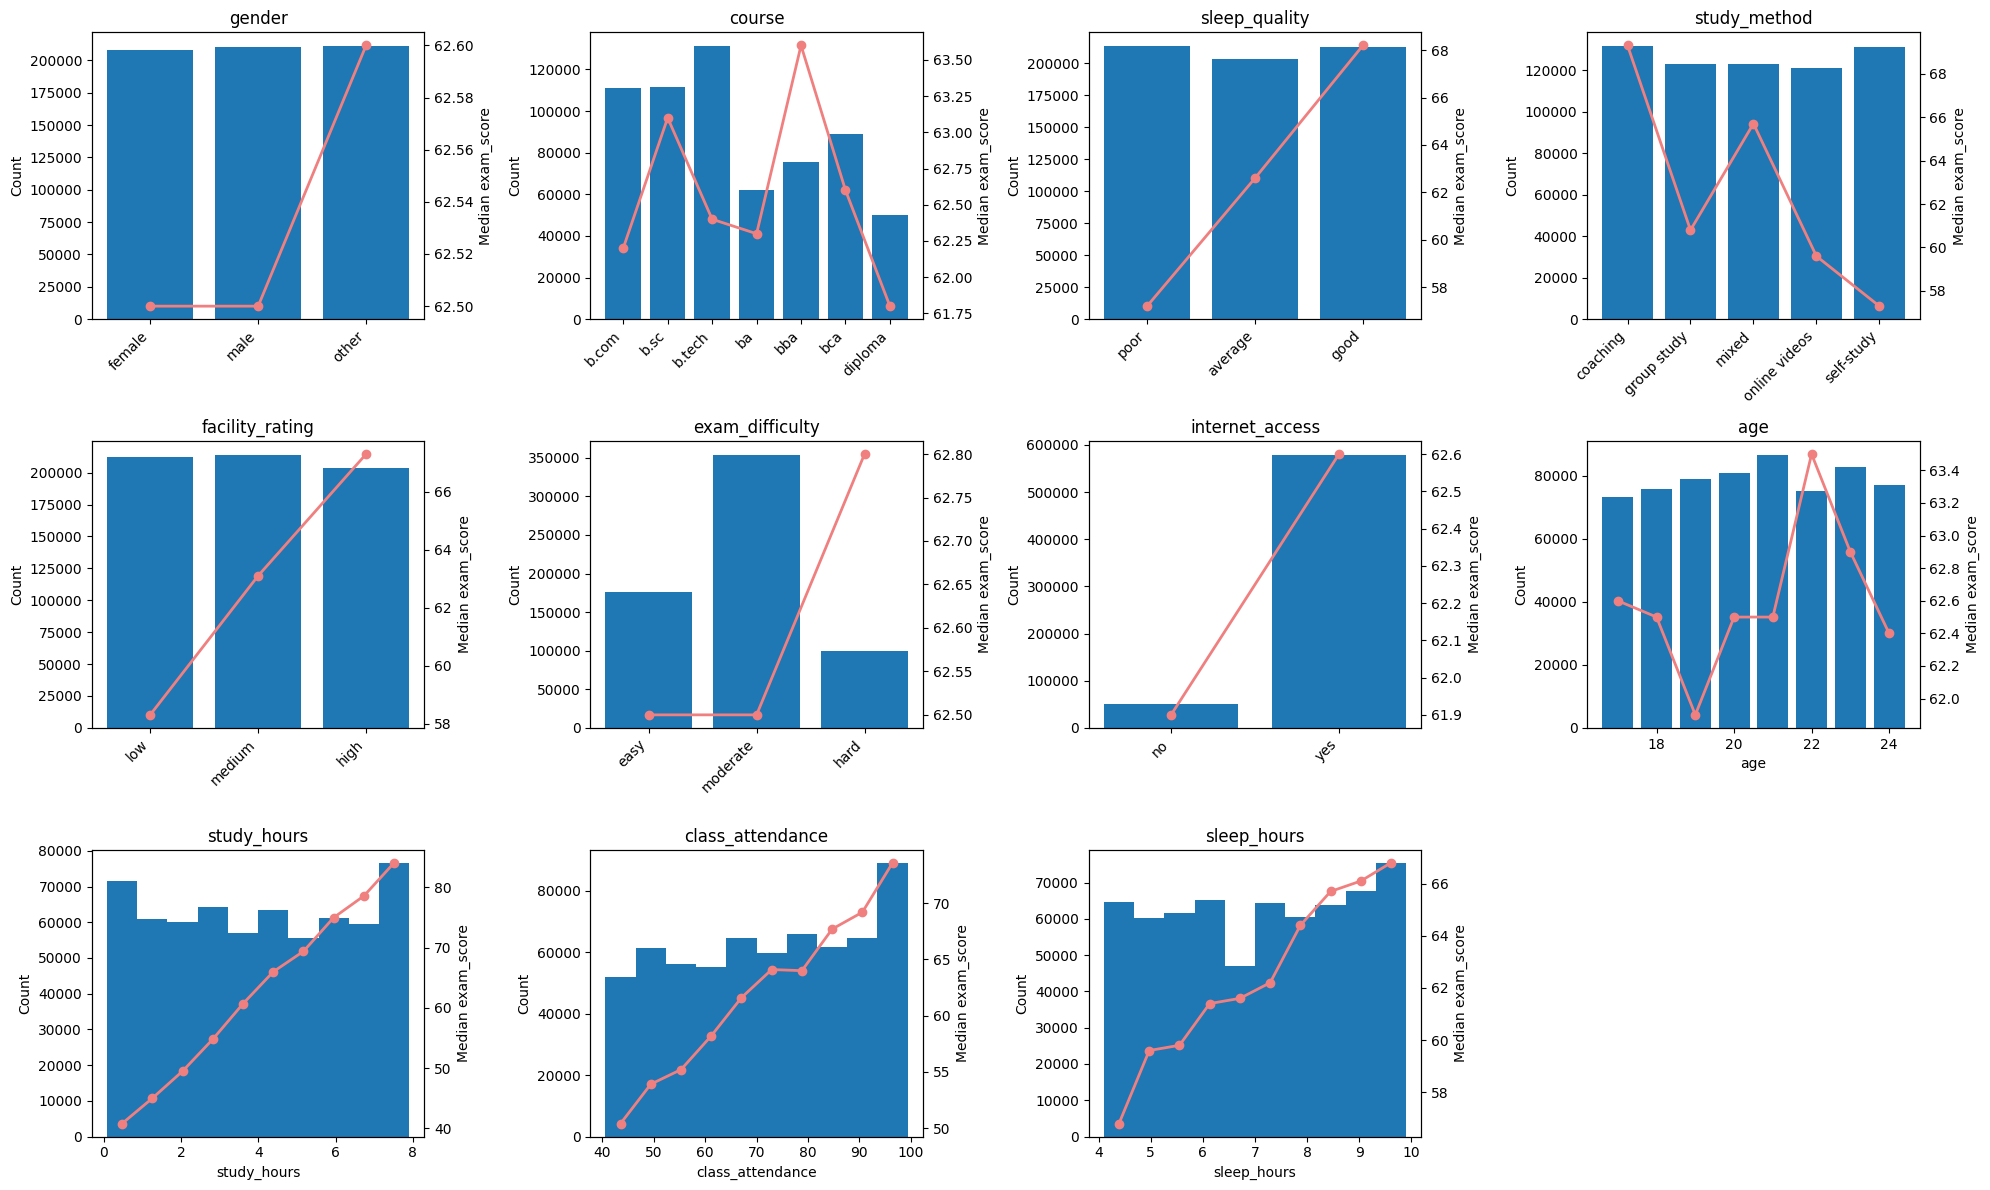

In [14]:
ordinal_order = {
    "sleep_quality": ["poor", "average", "good"],
    "facility_rating": ["low", "medium", "high"],
    "exam_difficulty": ["easy", "moderate", "hard"],
}

plot_count_and_median(df_train, cat_var + num_var, target, bins=10, ncols=4,
                      int_as_cat_unique_max=20, cat_order=ordinal_order)


### Key takeaways from the count + target-trend plots

**Strongest signals**
- The plots suggest that study behavior variables (e.g., study_hours, class_attendance, sleep_hours) have clear directional relationships with exam_score.

**Ordinal patterns**
- sleep_quality, facility_rating, and exam_difficulty appear to behave like **ordinal** variables (ordered levels correspond to consistent changes in exam_score).
- These are encoded as **ordered numeric mappings** (0/1/2) to preserve their natural rank.

**Imbalance**
- internet_access appears imbalanced (one level occurs much more frequently). This is not necessarily an issue, but it’s worth keeping in mind for evaluation and interpretation.

**Nominal variables**
- course and study_method are best treated as nominal (no natural ranking). Any apparent “ordering” in the plot should not be interpreted as a true scale.


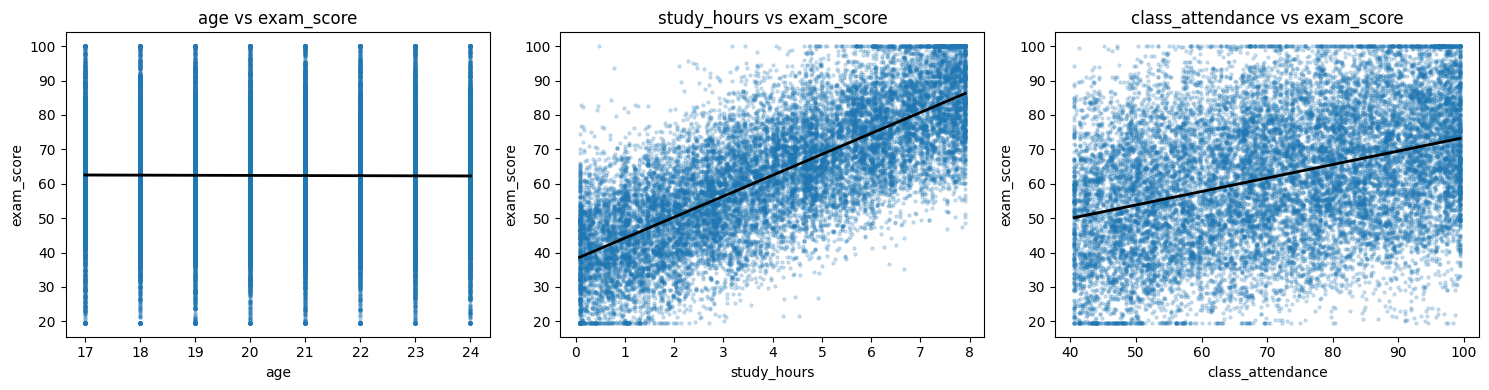

In [15]:
sample = df_train.sample(min(20000, len(df_train)), random_state=69)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  
axes = np.array(axes).ravel()

for ax, feature in zip(axes, num_var[:3]): 
    sns.regplot(
        data=sample, x=feature, y=target, ax=ax,
        scatter_kws={"s": 5, "alpha": 0.2},
        line_kws={"linewidth": 2, "color": "black"}
    )
    ax.set_title(f"{feature} vs {target}")
    ax.set_xlabel(feature)
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()


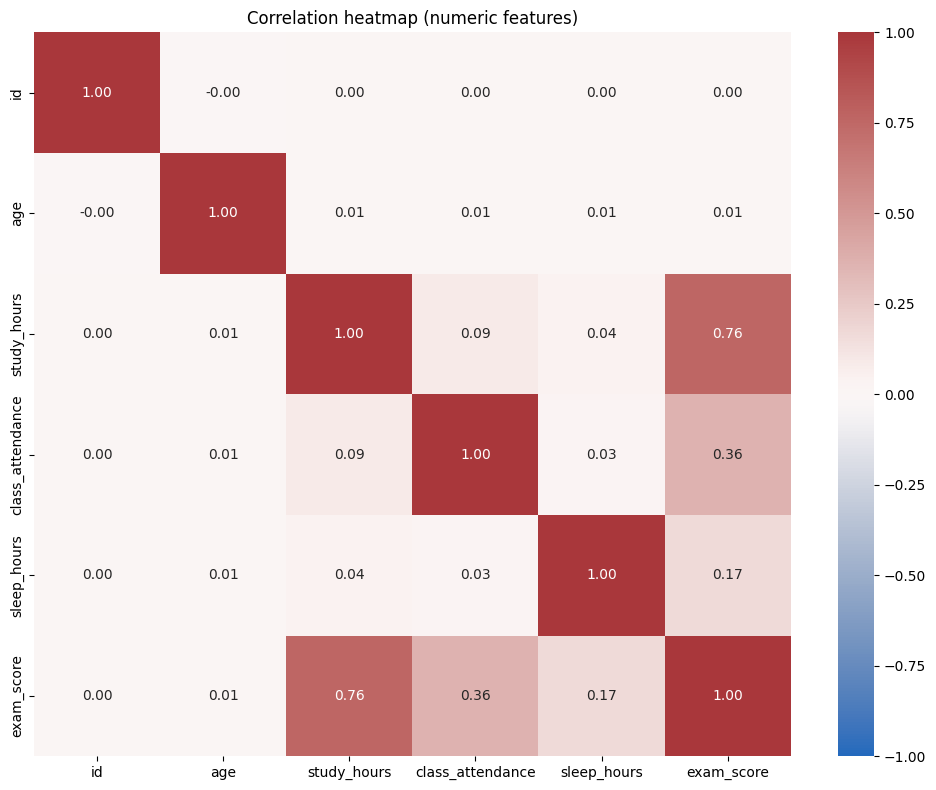

In [16]:
corr = df_train.select_dtypes("number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="vlag", center=0)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

## EDA summary and modeling implications

**Data quality**
- Dataset appears clean (no missing/duplicates checked above)

**Predictiveness**
- Study behavior features (study_hours, class_attendance, sleep_hours) show the clearest relationships with exam_score
- Additional ordinal variables also show consistent directional effect

**Encoding plan**
- Treat as **ordinal**: sleep_quality, facility_rating, exam_difficulty encoded as numeric mappings (0/1/2) and also passed as `category` dtype to XGBoost.
- Treat as **nominal** (no inherent order): gender, course, study_method, internet_access.

**Next steps**
- Move into feature engineering/encoding using the above decisions.
- Establish baseline models and compare performance using a consistent cross-validation setup.

# Feature Engineering

### Treating Continuous Features as Categorical for XGBoost

Four base numeric features, `age`, `study_hours`, `class_attendance`, and `sleep_hours`,  are cast to `category` dtype before being passed to XGBoost, even though engineered float versions of the same features are also included.

This comes down to how XGBoost splits features. In `hist` mode (its default), XGBoost bins continuous values and makes threshold splits (e.g. "study_hours < 4.0"). When a feature is marked as `category`, XGBoost instead uses a categorical split algorithm that groups distinct values by gradient statistics, essentially an exhaustive partition search over the actual observed values rather than a simple threshold.

For features like `study_hours` (792 unique values) or `class_attendance` (617 unique values), this matters because the relationship with exam score may not be cleanly monotone; students at specific hour counts can cluster together in ways a threshold split misses.

Crucially, this does not replace the engineered versions. Both representations exist simultaneously:
- The categorical version lets XGBoost find non-monotone, value-specific patterns in the raw feature
- The engineered float versions (`study_hours_squared`, `log_study_hours`, `sqrt_study_hours`, bins, etc.) let XGBoost find smooth, monotone relationships via threshold splits

This dual representation gives XGBoost two complementary views of each feature simultaneously; value-specific categorical splits and smooth threshold-based splits, rather than forcing a single representation that may miss part of the signal.

In [17]:
df_train["course"] = df_train["course"].map(course_notes)
df_test["course"] = df_test["course"].map(course_notes)
df_original["course"] = df_original["course"].map(course_notes)


In [18]:
print(f"\n{'-'*80}")
print("FEATURE ENGINEERING START")
print(f"\n{'-'*80}")

def transform_cat_cols(df):

    df_temp = df.copy()

    for c in cat_var:
        df_temp[c] = df_temp[c].astype('category')

    # Ordinal variables
    df_temp['sleep_quality_numeric'] = df_temp['sleep_quality'].map({'poor': 0, 'average': 1, 'good': 2}).astype(float)
    df_temp['facility_rating_numeric'] = df_temp['facility_rating'].map({'low': 0, 'medium': 1, 'high': 2}).astype(float)
    df_temp['exam_difficulty_numeric'] = df_temp['exam_difficulty'].map({'easy': 0, 'moderate': 1, 'hard': 2}).astype(float)

    return df_temp

def numeric_col_transformation(df):

    df_temp = df.copy()
    eps = 1e-6

    # Simple polynomials (2nd order only)
    df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
    df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
    df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2

    # Log transforms
    sh_pos = df_temp['study_hours'].clip(lower=0)
    ca_pos = df_temp['class_attendance'].clip(lower=0)
    sl_pos = df_temp['sleep_hours'].clip(lower=0)

    df_temp['log_study_hours'] = np.log1p(sh_pos)
    df_temp['log_class_attendance'] = np.log1p(ca_pos)
    df_temp['log_sleep_hours'] = np.log1p(sl_pos)

    # Sqrt transforms
    df_temp['sqrt_study_hours'] = np.sqrt(sh_pos)
    df_temp['sqrt_class_attendance'] = np.sqrt(ca_pos)
    df_temp["sqrt_sleep_hours"] = np.sqrt(sl_pos)

    # Key interactions
    df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
    df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']

    # Important ratios
    df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)
    df_temp['attendance_over_study'] = df_temp['class_attendance'] / (df_temp['study_hours'] + eps)

    # Ordinal × numeric interactions
    df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality_numeric']
    df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating_numeric']
    df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty_numeric']

    # Ordinal × ordinal interactions
    df_temp['facility_times_sleepq'] = df_temp['facility_rating_numeric'] * df_temp['sleep_quality_numeric']
    df_temp['difficulty_times_facility'] = df_temp['exam_difficulty_numeric'] * df_temp['facility_rating_numeric']

    # Rule-based flags
    df_temp["high_att_high_study"] = ((df_temp["class_attendance"] >= 90) & (df_temp["study_hours"] >= 6)).astype(int)
    df_temp["ideal_sleep_flag"] = ((df_temp["sleep_hours"] >= 7) & (df_temp["sleep_hours"] <= 9)).astype(int)
    df_temp["high_study_flag"] = (df_temp["study_hours"] >= 7).astype(int)

    # Composite efficiency
    df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)

    # Binned features
    df_temp["age_bin_num"] = pd.cut(df_temp["age"], bins=[0,17,19,21,23,100], labels=[0,1,2,3,4]).astype(float)
    df_temp["study_bin_num"] = pd.cut(df_temp["study_hours"], bins=[-1,2,4,6,8,100], labels=[0,1,2,3,4]).astype(float)
    df_temp["sleep_bin_num"] = pd.cut(df_temp["sleep_hours"], bins=[-1,5,6,7,8,100], labels=[0,1,2,3,4]).astype(float)
    df_temp["attendance_bin_num"] = pd.cut(df_temp["class_attendance"], bins=[-1,60,75,85,95,101], labels=[0,1,2,3,4]).astype(float)

    # Gap features
    df_temp['sleep_gap_8'] = (df_temp['sleep_hours'] - 8.0).abs()
    df_temp['attendance_gap_100'] = (df_temp['class_attendance'] - 100.0).abs()

    df_temp["age_squared"] = df_temp["age"] ** 2
    df_temp["age_times_study_hours"] = df_temp["age"] * df_temp["study_hours"]
    
    new_cols = ['study_hours_squared', 'class_attendance_squared', \
               'sleep_hours_squared', 'log_study_hours', 'log_class_attendance', \
               'log_sleep_hours', 'sqrt_study_hours', 'sqrt_class_attendance', \
               "sqrt_sleep_hours", 'study_hours_times_attendance', 'study_hours_times_sleep', \
               'attendance_times_sleep', 'study_hours_over_sleep', 'attendance_over_sleep', \
               'attendance_over_study', 'study_hours_times_sleep_quality', \
               'attendance_times_facility', 'sleep_hours_times_difficulty', \
               'facility_times_sleepq', 'difficulty_times_facility', \
               "high_att_high_study", "ideal_sleep_flag", "high_study_flag", \
               'efficiency', "age_bin_num", "study_bin_num", "sleep_bin_num", \
               "attendance_bin_num", 'sleep_gap_8', 'attendance_gap_100', \
               "age_squared", "age_times_study_hours"]

    return df_temp, new_cols

X_raw = df_train.drop(columns=['id', target])
y = df_train[target]

print(f"Original Base feature count: {len(X_raw.columns)}")

X = transform_cat_cols(X_raw)
print(f"Columns after categorical transform: {len(X.columns)}")
X, new_cols = numeric_col_transformation(X)

X_test = transform_cat_cols(df_test)
X_test, _ = numeric_col_transformation(X_test)

X_orig = transform_cat_cols(df_original)
X_orig, _ = numeric_col_transformation(X_orig)

X_test = X_test.reindex(columns=X.columns, fill_value=0)
X_orig = X_orig.reindex(columns=X.columns, fill_value=0)
y_orig = df_original[target]

print(f"Engineered numeric features: {len(new_cols)}")
print(f"Total features: {X.shape[1]}")



--------------------------------------------------------------------------------
FEATURE ENGINEERING START

--------------------------------------------------------------------------------
Original Base feature count: 11
Columns after categorical transform: 14
Engineered numeric features: 32
Total features: 46


## Formula Feature (Reverse-Engineered Data-Generating Process)

The synthetic dataset was generated from an approximately linear scoring function. The formula below was reverse-engineered from the data via Tobit model MLE and validated by the community using Lasso and Genetic Programming.

$$
\hat{y} = 6.0 \cdot \text{study\_hours} + 0.35 \cdot \text{class\_attendance} + 1.5 \cdot \text{sleep\_hours} + \delta_{\text{sleep\_quality}} + \delta_{\text{study\_method}} + \delta_{\text{facility\_rating}}
$$

where the categorical offsets are:

| Feature | Level | Offset |
|---|---|---|
| `sleep_quality` | good / average / poor | +9 / +4 / −5 |
| `study_method` | coaching / mixed / group study / online videos / self-study | +7 / +3 / +1 / −1 / −2 |
| `facility_rating` | high / medium / low | +4 / 0 / −4 |

Credit: [siukeitin](https://www.kaggle.com/siukeitin) and [mirko45](https://www.kaggle.com/mirko45)

In [19]:
sq_map = {'poor': -5, 'average': 4, 'good': 9}
sm_map = {'coaching': 7, 'mixed': 3, 'group study': 1, 'online videos': -1, 'self-study': -2}
fr_map = {'high': 4, 'medium': 0, 'low': -4}

for df in [X, X_test, X_orig]:
    df['formula'] = (
        6.0  * df['study_hours'].astype(float) +
        0.35 * df['class_attendance'].astype(float) +
        1.5  * df['sleep_hours'].astype(float) +
        df['sleep_quality'].astype(str).map(sq_map).fillna(0) +
        df['study_method'].astype(str).map(sm_map).fillna(0) +
        df['facility_rating'].astype(str).map(fr_map).fillna(0)
    ).astype(float)

print(f"Formula feature added. Total features: {X.shape[1]}")

Formula feature added. Total features: 47


# MODELING

## Reference Baseline

A mean-prediction baseline, predicting the training mean (62.5) for every sample, yields RMSE ≈ 18.9, equal to the standard deviation of `exam_score`. This is the reference floor: any model that learns meaningful structure should substantially outperform it.

XGBoost's iteration-0 validation RMSE (~18.2, visible in the training output below) confirms the pipeline is initialized near this baseline. The progression from ~18.2 → 8.647 (XGBoost OOF) → 8.632 (Ridge stack) measures the cumulative contribution of feature engineering, model capacity, and ensembling respectively.

In [ ]:
print(f"\n{'-'*80}")
print("FINALIZING BOOSTING DATASET")
print('-'*80)

kf = KFold(n_splits=FOLDS, shuffle=True, random_state=69)

X = X.copy()
X_test = X_test.copy()
X_orig = X_orig.copy()

# cast base numeric features to category alongside string categoricals
cat_cols = ["gender", "course", "internet_access", "sleep_quality",
            "study_method", "facility_rating", "exam_difficulty",
            "age", "study_hours", "class_attendance", "sleep_hours"]

numeric_cols = [c for c in X.columns if c not in cat_cols]

X_base = X.reset_index(drop=True).copy()
y_base = y.reset_index(drop=True).copy()

X_full = pd.concat([X_base, X_orig.reset_index(drop=True)], axis=0, ignore_index=True)
y_full = pd.concat([y_base, y_orig.reset_index(drop=True)], axis=0, ignore_index=True)

for c in cat_cols:
    X_full[c] = X_full[c].astype(str).astype("category")
    X_test[c] = X_test[c].astype(str).astype("category")

for c in numeric_cols:
    X_full[c] = X_full[c].astype(float)
    X_test[c] = X_test[c].astype(float)

print(f"Final feature count: {X.shape[1]}")



--------------------------------------------------------------------------------
FINALIZING BOOSTING DATASET
--------------------------------------------------------------------------------
Final feature count: 47


---
## Ensemble Architecture

This notebook trains three base models (XGBoost, LightGBM, MLP) on the same folds and blends their OOF predictions using Ridge regression as the final meta-learner.

**Ridge as the final blender**
Ridge finds the optimal regularized linear combination of each model's predictions. A tree-based meta-learner would risk overfitting by learning nonlinear patterns in the OOFs.

**XGBoost + LightGBM + MLP**
XGB and LGBM are both gradient boosted trees but grow trees differently (depth-wise vs. leaf-wise), providing moderate structural diversity. The MLP was included as an architectural diversity candidate: neural nets learn smooth continuous functions and make fundamentally different errors than threshold-based tree models, which in principle lowers prediction correlation and benefits the ensemble. Whether the MLP achieves genuine complementarity on this tabular task, and how the Ridge meta-learner weights it, is discussed in the interpretability section.

**Why the formula feature?**
The dataset is synthetic, generated from an approximately linear scoring function. By reverse-engineering the data-generating process, we construct a single feature that directly approximates the true latent exam score before noise is added: more information-dense than any nonlinear transform of individual columns.

---

## XGBoost Training

In [21]:
_n_base = len(X_base)
_orig_idx = np.arange(_n_base, len(X_full))

# Fixed params — no tuning needed; Ridge meta-learner handles the combination
best_params = {
    "learning_rate":    0.05,
    "max_depth":        6,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 3,
    "reg_alpha":        0.1,
    "reg_lambda":       1.0,
}
print("XGBoost using fixed hyperparameters:", best_params)

XGBoost using fixed hyperparameters: {'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'reg_alpha': 0.1, 'reg_lambda': 1.0}


In [ ]:
print(f"\n{'-'*80}")
print("TRAINING XGBOOST")
print("-"*80)

xgb_params = {
    "n_estimators": 2000,
    **best_params,
    "tree_method": "hist",
    "nthread": -1,
    "random_state": 69,
    "early_stopping_rounds": 50,
    "eval_metric": "rmse",
    "enable_categorical": True,
    "device": DEVICE,
}

n_base = len(X_base)
orig_idx = np.arange(n_base, len(X_full))

oof_predictions = np.zeros(n_base)
test_predictions = np.zeros(len(X_test))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_base, y_base), 1):
    tr_full_idx = np.concatenate([tr_idx, orig_idx])

    X_tr = X_full.iloc[tr_full_idx]
    y_tr = y_full.iloc[tr_full_idx]

    X_va = X_full.iloc[va_idx]
    y_va = y_full.iloc[va_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=500
    )

    val_preds = model.predict(X_va)
    oof_predictions[va_idx] = val_preds
    test_predictions += model.predict(X_test) / FOLDS

    rmse_fold = np.sqrt(mean_squared_error(y_va, val_preds))
    print(f"Fold {fold} RMSE: {rmse_fold:.5f} | best_iter={model.best_iteration}")

X_shap = X_va 
xgb_oof_rmse = np.sqrt(mean_squared_error(y_base, oof_predictions))
print("OOF RMSE:", xgb_oof_rmse)


--------------------------------------------------------------------------------
TRAINING XGBOOST
--------------------------------------------------------------------------------
[0]	validation_0-rmse:18.22914
[235]	validation_0-rmse:8.62853
Fold 1 RMSE: 8.62661 | best_iter=185
[0]	validation_0-rmse:18.27839
[283]	validation_0-rmse:8.71067
Fold 2 RMSE: 8.71039 | best_iter=233
[0]	validation_0-rmse:18.13937
[265]	validation_0-rmse:8.62105
Fold 3 RMSE: 8.61936 | best_iter=215
[0]	validation_0-rmse:18.20302
[216]	validation_0-rmse:8.64953
Fold 4 RMSE: 8.64863 | best_iter=166
[0]	validation_0-rmse:18.30227
[283]	validation_0-rmse:8.64896
Fold 5 RMSE: 8.64694 | best_iter=233
[0]	validation_0-rmse:18.25385
[236]	validation_0-rmse:8.66411
Fold 6 RMSE: 8.66273 | best_iter=186
[0]	validation_0-rmse:18.24789
[232]	validation_0-rmse:8.62730
Fold 7 RMSE: 8.62664 | best_iter=182
[0]	validation_0-rmse:18.20063
[302]	validation_0-rmse:8.62602
Fold 8 RMSE: 8.62323 | best_iter=252
[0]	validation_0-rms

## LightGBM Training

*Note: categorical features are encoded as integer codes (`.cat.codes`) rather than using LightGBM's native `categorical_feature` parameter, which would require explicitly passing column names to `.fit()`. As a result, LightGBM treats these as ordinal numerics rather than true categoricals unlike XGBoost's `enable_categorical=True`. This is a known limitation of the current implementation.*

In [ ]:
# Prepare LightGBM data (category to int codes)
X_full_lgb = X_full.copy()
X_test_lgb  = X_test.copy()
for col in cat_cols:
    X_full_lgb[col] = X_full_lgb[col].cat.codes
    X_test_lgb[col]  = X_test_lgb[col].cat.codes

# Fixed params — no tuning needed; Ridge meta-learner handles the combination
best_lgb_params = {
    "learning_rate":     0.05,
    "num_leaves":        127,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "min_child_samples": 20,
    "reg_alpha":         0.1,
    "reg_lambda":        1.0,
}
print("LightGBM using fixed hyperparameters:", best_lgb_params)

# Full OOF training
print(f"\n{'-'*80}")
print("TRAINING LIGHTGBM")
print("-"*80)

lgb_final_params = {
    "n_estimators": 5000,
    **best_lgb_params,
    "random_state": 69, "n_jobs": 1, "verbose": -1,
}

lgb_oof = np.zeros(n_base)
lgb_test_preds = np.zeros(len(X_test_lgb))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_full_lgb.iloc[:n_base], y_base), 1):
    tr_full = np.concatenate([tr_idx, orig_idx])
    X_tr, y_tr = X_full_lgb.iloc[tr_full], y_full.iloc[tr_full]
    X_va, y_va = X_full_lgb.iloc[va_idx],  y_full.iloc[va_idx]
    model_lgb = lgb.LGBMRegressor(**lgb_final_params)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                  categorical_feature=cat_cols,
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(500)])
    val_preds          = model_lgb.predict(X_va)
    lgb_oof[va_idx]    = val_preds
    lgb_test_preds    += model_lgb.predict(X_test_lgb) / FOLDS
    print(f"  Fold {fold} RMSE: {np.sqrt(mean_squared_error(y_va, val_preds)):.5f}")

lgb_oof_rmse = np.sqrt(mean_squared_error(y_base, lgb_oof))
print(f"LightGBM OOF RMSE: {lgb_oof_rmse:.6f}")

LightGBM using fixed hyperparameters: {'learning_rate': 0.05, 'num_leaves': 127, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 20, 'reg_alpha': 0.1, 'reg_lambda': 1.0}

--------------------------------------------------------------------------------
TRAINING LIGHTGBM
--------------------------------------------------------------------------------
[500]	valid_0's l2: 76.0726
  Fold 1 RMSE: 8.71861
[500]	valid_0's l2: 77.692
  Fold 2 RMSE: 8.81241
[500]	valid_0's l2: 76.0869
  Fold 3 RMSE: 8.72186
[500]	valid_0's l2: 76.2829
  Fold 4 RMSE: 8.73155
[500]	valid_0's l2: 76.2999
  Fold 5 RMSE: 8.73167
[500]	valid_0's l2: 76.682
  Fold 6 RMSE: 8.75510
[500]	valid_0's l2: 76.4145
  Fold 7 RMSE: 8.73744
[500]	valid_0's l2: 75.9625
  Fold 8 RMSE: 8.71177
[500]	valid_0's l2: 76.8827
  Fold 9 RMSE: 8.76308
[500]	valid_0's l2: 76.4285
  Fold 10 RMSE: 8.74013
LightGBM OOF RMSE: 8.742406


## MLP Training

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else "cpu"
)
print(f"Device: {device}")

# Dataset and model 
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class MLP(nn.Module):
    def __init__(self, in_dim, layer_size, n_layers, dropout):
        super().__init__()
        layers = []
        for i in range(n_layers):
            layers += [
                nn.Linear(in_dim if i == 0 else layer_size, layer_size),
                nn.BatchNorm1d(layer_size),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
        layers.append(nn.Linear(layer_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

# Single-fold trainer 
def train_one_fold(X_tr, y_tr, X_va, y_va, X_te, params, seed=69, fold_num=1):
    torch.manual_seed(seed)
    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr).astype(np.float32)
    X_va_s  = scaler.transform(X_va).astype(np.float32)
    X_te_s  = scaler.transform(X_te).astype(np.float32)

    loader = DataLoader(
        TabularDataset(X_tr_s, y_tr.astype(np.float32)),
        batch_size=params["batch_size"], shuffle=True,
    )
    model   = MLP(X_tr_s.shape[1], params["layer_size"],
                  params["n_layers"], params["dropout"]).to(device)
    opt     = torch.optim.Adam(model.parameters(),
                               lr=params["lr"], weight_decay=params["weight_decay"])
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=params["epochs"])
    loss_fn = nn.MSELoss()

    val_X  = torch.tensor(X_va_s).to(device)
    test_X = torch.tensor(X_te_s).to(device)

    best_rmse     = float("inf")
    best_va_preds = None
    best_te_preds = None
    no_improve    = 0

    for epoch in range(params["epochs"]):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            va_preds = model(val_X).cpu().numpy()
            te_preds = model(test_X).cpu().numpy()
        rmse = np.sqrt(mean_squared_error(y_va, va_preds))

        if rmse < best_rmse:
            best_rmse, best_va_preds, best_te_preds = rmse, va_preds.copy(), te_preds.copy()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= params["patience"]:
                break

        if (epoch + 1) % 10 == 0:
            print(f"    Fold {fold_num} | Epoch {epoch+1:3d}/{params['epochs']} | Best RMSE: {best_rmse:.5f} | No improve: {no_improve}")

    return best_va_preds, best_te_preds, best_rmse

mlp_feature_cols = [c for c in X_full.columns if str(X_full[c].dtype) != 'category']
X_full_mlp = X_full[mlp_feature_cols].astype(float).values
X_test_mlp  = X_test[mlp_feature_cols].astype(float).values

# Fixed params — no tuning needed; Ridge meta-learner handles the combination
best_mlp = {
    "n_layers":     3,
    "layer_size":   256,
    "lr":           1e-3,
    "dropout":      0.2,
    "weight_decay": 1e-4,
    "batch_size":   8192,
    "epochs":       100,
    "patience":     5,
}
print("MLP using fixed hyperparameters:", best_mlp)

# Full OOF training 
print(f"\n{'-'*80}")
print("TRAINING MLP (PyTorch)")
print("-"*80)

mlp_oof        = np.zeros(n_base)
mlp_test_preds = np.zeros(len(X_test_mlp))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_full_mlp[:n_base], y_base), 1):
    tr_full = np.concatenate([tr_idx, orig_idx])
    va_preds, te_preds, fold_rmse = train_one_fold(
        X_full_mlp[tr_full],  y_full.iloc[tr_full].values,
        X_full_mlp[va_idx],   y_base.iloc[va_idx].values,
        X_test_mlp, best_mlp, seed=69, fold_num=fold,
    )
    mlp_oof[va_idx]   = va_preds
    mlp_test_preds   += te_preds / FOLDS
    print(f"  Fold {fold} RMSE: {fold_rmse:.5f}")

mlp_oof_rmse = np.sqrt(mean_squared_error(y_base, mlp_oof))
print(f"MLP OOF RMSE: {mlp_oof_rmse:.6f}")


Device: cpu
MLP using fixed hyperparameters: {'n_layers': 3, 'layer_size': 256, 'lr': 0.001, 'dropout': 0.2, 'weight_decay': 0.0001, 'batch_size': 8192, 'epochs': 100, 'patience': 15}

--------------------------------------------------------------------------------
TRAINING MLP (PyTorch)
--------------------------------------------------------------------------------
    Fold 1 | Epoch  10/100 | Best RMSE: 8.86344 | No improve: 0
    Fold 1 | Epoch  20/100 | Best RMSE: 8.84851 | No improve: 5
    Fold 1 | Epoch  30/100 | Best RMSE: 8.83504 | No improve: 0
    Fold 1 | Epoch  40/100 | Best RMSE: 8.83504 | No improve: 10
  Fold 1 RMSE: 8.83504
    Fold 2 | Epoch  10/100 | Best RMSE: 8.98796 | No improve: 1
    Fold 2 | Epoch  20/100 | Best RMSE: 8.94183 | No improve: 4
    Fold 2 | Epoch  30/100 | Best RMSE: 8.93248 | No improve: 1
    Fold 2 | Epoch  40/100 | Best RMSE: 8.93248 | No improve: 11
    Fold 2 | Epoch  50/100 | Best RMSE: 8.92642 | No improve: 3
    Fold 2 | Epoch  60/100 | 

In [ ]:
print(f"\n{'='*80}")
print("RIDGE META-STACK ENSEMBLE")
print("="*80)

stack_train = np.column_stack([oof_predictions, lgb_oof, mlp_oof])
stack_test  = np.column_stack([test_predictions, lgb_test_preds, mlp_test_preds])

meta_ridge = RidgeCV(alphas=np.logspace(-3, 3, 20), cv=5)
meta_ridge.fit(stack_train, y_base)

final_preds = np.clip(meta_ridge.predict(stack_test), 0, 100)
meta_oof_rmse = np.sqrt(mean_squared_error(y_base, meta_ridge.predict(stack_train)))

print(f"\nBase Model OOF RMSE:")
print(f"  XGBoost:              {xgb_oof_rmse:.6f}")
print(f"  LightGBM:             {lgb_oof_rmse:.6f}")
print(f"  MLP:                  {mlp_oof_rmse:.6f}")
print(f"\nRidge Stack OOF RMSE:  {meta_oof_rmse:.6f}")
print(f"Stack weights XGB: {meta_ridge.coef_[0]:.3f}, LGBM: {meta_ridge.coef_[1]:.3f}, MLP: {meta_ridge.coef_[2]:.3f}")

oof_df = pd.DataFrame({
    "id":      df_train["id"],
    "xgb_oof": oof_predictions,
    "lgb_oof": lgb_oof,
    "mlp_oof": mlp_oof,
    target:    y_base,
})
oof_df.to_csv("outputs/all_oofs.csv", index=False)
print(f"Saved: all_oofs.csv")


RIDGE META-STACK ENSEMBLE

Base Model OOF RMSE:
  XGBoost:              8.647274
  LightGBM:             8.742406
  MLP:                  8.857036

Ridge Stack OOF RMSE:  8.631648
Stack weights — XGB: 0.756, LGBM: 0.410, MLP: -0.166
Saved: all_oofs.csv



--------------------------------------------------------------------------------
RESIDUAL ANALYSIS
--------------------------------------------------------------------------------


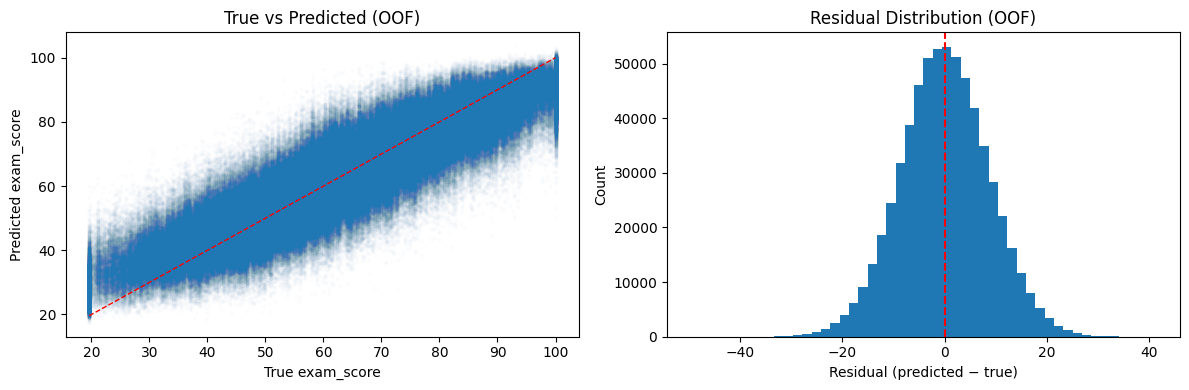

In [27]:
print(f"\n{'-'*80}")
print("RESIDUAL ANALYSIS (Ridge Stack)")
print('-'*80)

ridge_oof = meta_ridge.predict(stack_train)
residuals = ridge_oof - y_base.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_base, ridge_oof, alpha=0.01, s=4)
axes[0].plot([y_base.min(), y_base.max()], [y_base.min(), y_base.max()], 'r--', linewidth=1)
axes[0].set_xlabel("True exam_score")
axes[0].set_ylabel("Predicted exam_score")
axes[0].set_title("True vs Predicted (Ridge Stack)")

axes[1].hist(residuals, bins=50)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel("Residual (predicted − true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution (Ridge Stack)")

plt.tight_layout()
plt.show()


--------------------------------------------------------------------------------
FEATURE IMPORTANCE (last fold)
--------------------------------------------------------------------------------


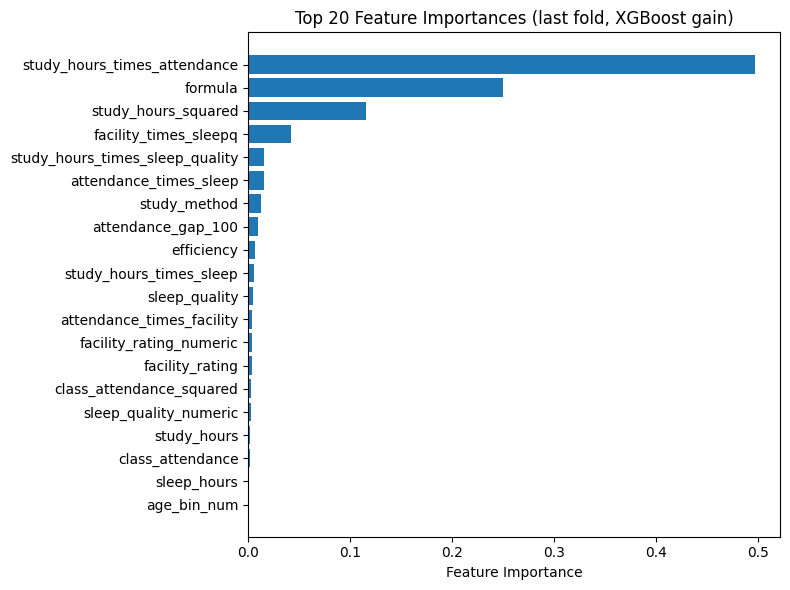

In [28]:
print(f"\n{'-'*80}")
print("FEATURE IMPORTANCE (last fold)")
print('-'*80)

feat_imp = pd.Series(model.feature_importances_, index=X_full.columns)
top20 = feat_imp.nlargest(20).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(top20.index, top20.values)
plt.xlabel("Feature Importance")
plt.title("Top 20 Feature Importances (last fold, XGBoost gain)")
plt.tight_layout()
plt.show()



--------------------------------------------------------------------------------
SHAP FEATURE IMPORTANCE
--------------------------------------------------------------------------------


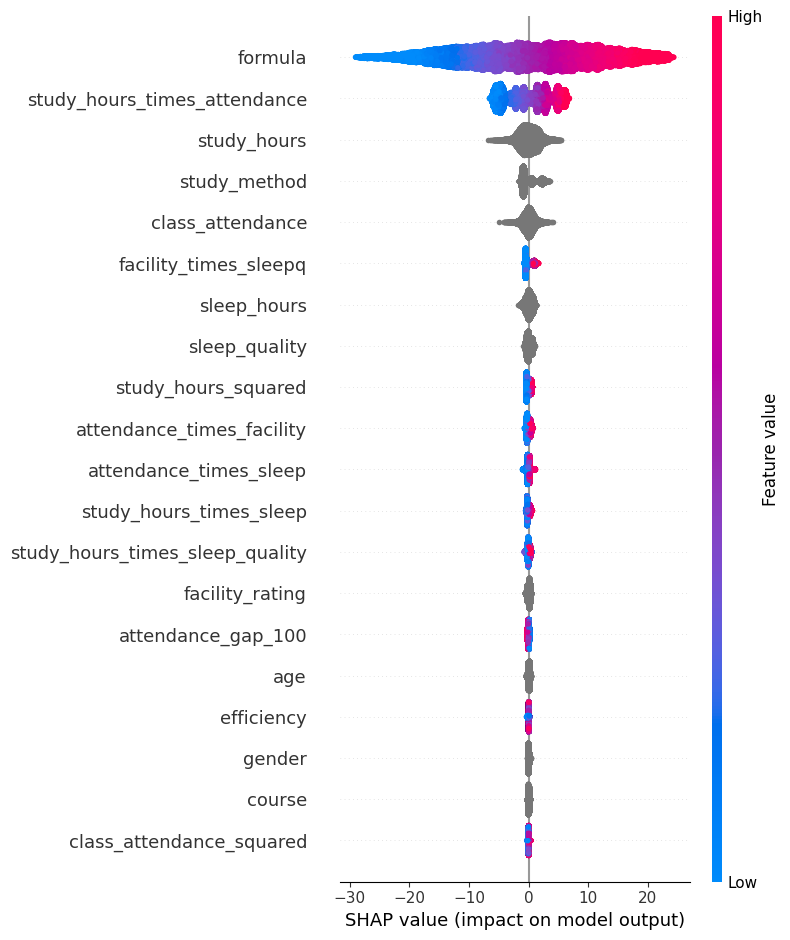

In [29]:
print(f"\n{'-'*80}")
print("SHAP FEATURE IMPORTANCE")
print('-'*80)

import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout()
plt.show()

## Interpretability Results

*Note: residual plots use `meta_ridge.predict(stack_train)` in-sample for the meta-learner, since Ridge is fit on all base-model OOFs at once. The reported OOF RMSE of 8.632 is the correct generalization estimate. Feature importance and SHAP reflect the final fold's XGBoost model on fold 10's held-out validation set; SHAP on Ridge itself would only reveal the three stacking weights. Single-fold SHAP rankings may have modest variance in the mid-tier; the high-level patterns (formula dominance, interaction feature ranking) are stable.*

### Residual Analysis

The true-vs-predicted scatter is tightly clustered around the identity diagonal with no visible systematic bias. The residual histogram is approximately bell-shaped and centered near zero, consistent with a well-specified regression model. Residual variance widens slightly at the extremes, characteristic of mean-reversion bias in tree models with finite depth.

### SHAP Interpretation

The beeswarm summary plot ranks features by mean absolute SHAP value; dot color encodes raw feature value (red = high, blue = low) and horizontal position encodes the direction and magnitude of the effect on the prediction.

**`formula`** dominates by a wide margin: it directly encodes the reverse-engineered DGP, compressing the six most predictive raw features into a single scalar. Its dominance reflects information density, not model overreliance.

**`study_hours_times_attendance`** is the highest-ranked non-formula feature. The interaction is more predictive than either component alone because it multiplicatively captures joint study effort, a student who studies extensively but rarely attends class receives a substantially lower score than one who does both.

Contextual interaction terms (e.g., **`study_hours_times_sleep_quality`**, **`attendance_times_facility`**) appear in the mid-tier, consistent with the interpretation that environmental and lifestyle factors modulate rather than independently drive exam performance. Raw base features (`study_hours`, `class_attendance`) carry relatively low direct SHAP importance: their signal is captured more efficiently by the engineered interaction, polynomial, and log-transformed versions.

### Alignment with EDA

The SHAP ranking directly validates EDA conclusions:

- `study_hours` × `class_attendance` is the dominant engineered feature, confirming joint study effort as the primary behavioral driver.
- Ordinal features (`sleep_quality`, `facility_rating`, `exam_difficulty`) contribute primarily through interaction terms, confirming their effects are conditional on study behavior rather than independent.
- `gender` and `internet_access` rank near the bottom, consistent with their weak individual target trends in EDA.

This alignment model-learned patterns matching pre-modeling analysis strengthens confidence that the model captures real structure.

## Conclusions, Takeaways, and Future Directions

### Main Conclusions

- **Study behavior dominates exam score prediction.** The interaction of `study_hours` and `class_attendance` is the most important engineered feature, and both are prominent contributors in the reverse-engineered formula. Together they explain the bulk of variance in exam score.
- **The formula feature is uniquely powerful.** By reverse-engineering the data-generating process, we constructed a single feature that compresses the six most predictive variables into an information-dense scalar. This was the highest-impact modeling decision in the pipeline.
- **Stacking provides a modest but consistent improvement.** The Ridge meta-learner achieved an OOF RMSE of **8.632\***, compared to XGBoost alone at **8.647**, a reliable gain from combining three structurally distinct models.
- **Model errors are approximately unbiased.** The residual distribution is roughly symmetric and centered near zero, with slight variance expansion at the extremes, consistent with a well-behaved regression model rather than systematic misspecification.

### Key Takeaways

| Model | OOF RMSE |
|---|---|
| XGBoost | 8.647 |
| LightGBM | 8.742 |
| MLP | 8.857 |
| **Ridge Stack** | **8.632\*** |

*\*Ridge Stack RMSE is computed in-sample for the meta-learner (Ridge fit on all base-model OOFs at once); base model RMSEs are true out-of-fold. The Ridge estimate is slightly optimistic, see the Interpretability section.*

- XGBoost substantially outperforms LightGBM and MLP as a standalone model and receives the highest meta-learner weight (0.756).
- The MLP receives a negative stacking weight (−0.166). While it falls short of full complementarity on this tabular task, its inclusion was a deliberate diversification choice: as the only non-tree model, it spans a fundamentally different region of the error surface (smooth continuous functions vs. threshold splits), and the Ridge meta-learner appropriately discounts it without requiring exclusion.
- Dual-representation of base numeric features, raw `category` dtype for XGBoost's categorical split algorithm alongside engineered float transforms, was a non-obvious design choice that improved RMSE over using either representation alone.
- Feature engineering contributed substantially more to predictive performance than model architecture choices: 47 total features from 11 base features, with the formula and interaction terms providing the largest individual gains.

*Ablation studies (raw features only, formula-excluded, single-model baselines) and hyperparameter search logs were run but omitted to keep the notebook focused on final results.*

### Potential Future Improvements

1. **Hyperparameter tuning**: All three base models used fixed hyperparameters. Systematic tuning (e.g., Bayesian optimization via Optuna) could improve each model individually before stacking.
2. **Additional base learners**: CatBoost (native ordered categorical support) and TabNet (attention-based tabular deep learning) could increase architectural diversity in the meta-stack.
3. **Improved neural network**: A residual-connection network with learned entity embeddings for categorical features could produce more competitive and complementary predictions.
4. **Feature selection**: With 47 features, some redundant polynomial transforms may introduce noise. SHAP-guided pruning could reduce feature count while preserving or improving generalization.
5. **Uncertainty quantification**: Quantile regression or conformal prediction intervals would add calibrated uncertainty bounds, particularly valuable near the score extremes where residual variance is elevated.